In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


In [4]:

X = np.array([[0,0], [0,1], [1,0],[1,1]])

y = np.array([[0],[1],[1],[0]])


In [5]:
np.random.seed(42)

input_size = 2
hidden_size = 4
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))


In [6]:
epochs = 10000
learning_rate = 0.1

loss_history = []

for epoch in range(epochs):

    z1 = np.dot(X, W1) + b1

  
    a1 = sigmoid(z1)

  
    z2 = np.dot(a1, W2) + b2

    y_hat = sigmoid(z2)

  

    loss = np.mean((y - y_hat) ** 2)
    loss_history.append(loss)

    d_loss_yhat = -(2/len(y)) * (y - y_hat)
    
    d_yhat_z2 = sigmoid_derivative(z2)
    d_z2_W2 = a1

    d_loss_z2 = d_loss_yhat * d_yhat_z2
    d_loss_W2 = np.dot(d_z2_W2.T, d_loss_z2)
    d_loss_b2 = np.sum(d_loss_z2, axis=0, keepdims=True)

    
    d_z2_a1 = W2
    d_loss_a1 = np.dot(d_loss_z2, d_z2_a1.T)

    d_a1_z1 = sigmoid_derivative(z1)
    d_loss_z1 = d_loss_a1 * d_a1_z1

    d_loss_W1 = np.dot(X.T, d_loss_z1)
    d_loss_b1 = np.sum(d_loss_z1, axis=0, keepdims=True)

    W1 -= learning_rate * d_loss_W1
    b1 -= learning_rate * d_loss_b1

    W2 -= learning_rate * d_loss_W2
    b2 -= learning_rate * d_loss_b2


    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")


Epoch 0, Loss: 0.25000116144925016
Epoch 1000, Loss: 0.2500000000874144
Epoch 2000, Loss: 0.2500000000873685
Epoch 3000, Loss: 0.2500000000873227
Epoch 4000, Loss: 0.25000000008727685
Epoch 5000, Loss: 0.25000000008723106
Epoch 6000, Loss: 0.2500000000871853
Epoch 7000, Loss: 0.2500000000871396
Epoch 8000, Loss: 0.25000000008709383
Epoch 9000, Loss: 0.25000000008704815


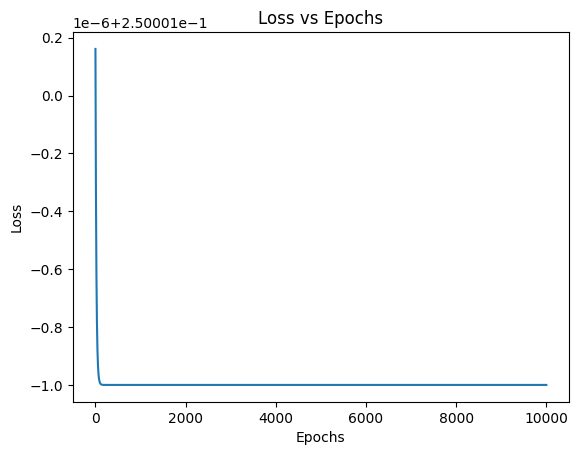

In [7]:
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()


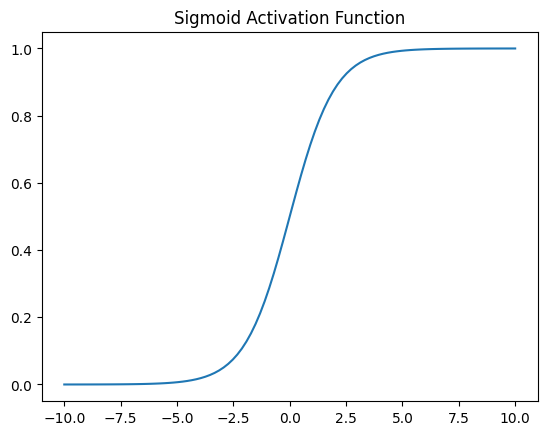

In [8]:
x_vals = np.linspace(-10, 10, 100)
plt.plot(x_vals, sigmoid(x_vals))
plt.title("Sigmoid Activation Function")
plt.show()


In [9]:
print("Final Predictions:")
print(y_hat)

print("Rounded Predictions:")
print(np.round(y_hat))


Final Predictions:
[[0.50000608]
 [0.50000046]
 [0.49999957]
 [0.49999395]]
Rounded Predictions:
[[1.]
 [1.]
 [0.]
 [0.]]
